In [1]:
%load_ext autoreload
%autoreload 2

### Environment Set Up

In [2]:
# Set the number of threads to use for running ML models
import os

os.environ["OMP_NUM_THREADS"] = str(os.cpu_count())

#### Importing Libraries
We begin by importing the necessary libraries for data analysis, visualization, and model building

In [3]:
# Import Necessary Packages and Module
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import shap

# Custom package - for loading, preprocessing, model development and evaluation
from utility.utility_functions import load_data,barplot,cormat,preprocess_data,fairness_check,load_model,model_report
from utility.model_training import train_and_evaluate_model 
from utility.cross_validate import model_val

# Setting number of folds for training and parameter tuning
from sklearn.model_selection import StratifiedKFold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

c:\Users\Aderoju\Desktop\Python Project\Credit Risk Modelling\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# Set Chart fontsize, number of columns for pandas DataFrame
pd.set_option('display.max_columns', 500)
pd.set_option('display.max_colwidth', 4000)
plt.style.use('ggplot')
mpl.rcParams['font.size'] = 10

### Loading the Dataset

Here, we will load the dataset into python environment, explore the dataset to understand its structure and identify any anomalies.

In [5]:
# specify the path to the dataset
data_path = r"raw/GermanCredit.csv"
df = load_data(data_path)

In [6]:
# Preliminary data check
df.head(1)

,checking_balance,months_loan_duration,credit_history,purpose,amount,savings_balance,employment_length,installment_rate,personal_status,other_debtors,residence_history,property,age,installment_plan,housing,existing_credits,default,dependents,telephone,foreign_worker,job,gender
0,-43.0,6,critical,radio/tv,1169,NaN,13 years,4,single,none,6 years,real estate,67,none,own,2,0,1,2.349340e+09,yes,skilled employee,male


### Data Cleaning & Exploratory Data Analysis (EDA)

Under this section, we will try to understand the various columns in the dataset, to enable us determine methods for handling these columns for cleaning, and further analysis. 

In [7]:
#Indicate the target column
target_column='default'

In [8]:
# Show The First 5 Rows of the Dataset
print(df.head())

   checking_balance  months_loan_duration credit_history    purpose  amount  \
0             -43.0                     6       critical   radio/tv    1169   
1              75.0                    48         repaid   radio/tv    5951   
2               NaN                    12       critical  education    2096   
3             -32.0                    42         repaid  furniture    7882   
4             -23.0                    24        delayed  car (new)    4870   

   savings_balance employment_length  installment_rate personal_status  \
0              NaN          13 years                 4          single   
1             89.0           2 years                 2             NaN   
2             24.0           5 years                 2          single   
3              9.0           5 years                 2          single   
4             43.0           3 years                 3          single   

  other_debtors residence_history                  property  age  \
0          n

In [48]:
# Show The Last 5 Rows of the Dataset
print(df.tail())

     checking_balance  months_loan_duration credit_history     purpose  \
995               NaN                    12         repaid   furniture   
996             -30.0                    30         repaid  car (used)   
997               NaN                    12         repaid    radio/tv   
998             -18.0                    45         repaid    radio/tv   
999             194.0                    45       critical  car (used)   

     amount  savings_balance employment_length  installment_rate  \
995    1736             48.0           4 years                 3   
996    3857             20.0           3 years                 4   
997     804             44.0          13 years                 4   
998    1845             31.0           2 years                 4   
999    4576            128.0               NaN                 3   

    personal_status other_debtors residence_history                  property  \
995             NaN          none          20 years              

In [9]:
# Show The Dimension of the Dataset
print(df.shape)

(1000, 22)


In [10]:
# Show the general information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   checking_balance      606 non-null    float64
 1   months_loan_duration  1000 non-null   int64  
 2   credit_history        1000 non-null   object 
 3   purpose               1000 non-null   object 
 4   amount                1000 non-null   int64  
 5   savings_balance       817 non-null    float64
 6   employment_length     938 non-null    object 
 7   installment_rate      1000 non-null   int64  
 8   personal_status       690 non-null    object 
 9   other_debtors         1000 non-null   object 
 10  residence_history     870 non-null    object 
 11  property              1000 non-null   object 
 12  age                   1000 non-null   int64  
 13  installment_plan      1000 non-null   object 
 14  housing               1000 non-null   object 
 15  existing_credits      

In [11]:
# Number of Missing Data By Column
print(df.isna().sum())

checking_balance        394
months_loan_duration      0
credit_history            0
purpose                   0
amount                    0
savings_balance         183
employment_length        62
installment_rate          0
personal_status         310
other_debtors             0
residence_history       130
property                  0
age                       0
installment_plan          0
housing                   0
existing_credits          0
default                   0
dependents                0
telephone               596
foreign_worker            0
job                       0
gender                    0
dtype: int64


In [12]:
# Number of Duplicated Rows
print(df.duplicated().sum())

0


In [53]:
# Number of Unique Values By column
print(df.nunique())

checking_balance        263
months_loan_duration     33
credit_history            5
purpose                  10
amount                  921
savings_balance         302
employment_length        31
installment_rate          4
personal_status           3
other_debtors             3
residence_history        36
property                  4
age                      53
installment_plan          3
housing                   3
existing_credits          4
default                   2
dependents                2
telephone               404
foreign_worker            2
job                       4
gender                    2
dtype: int64


In [13]:
# Descriptive statistics for the numeric features 
print(df.describe(include=['float','int']))

       checking_balance  months_loan_duration        amount  savings_balance  \
count        606.000000           1000.000000   1000.000000       817.000000   
mean          97.245875             20.903000   3271.258000       781.570379   
std          206.923583             12.058814   2822.736876      3016.983785   
min          -50.000000              4.000000    250.000000         0.000000   
25%          -23.000000             12.000000   1365.500000        31.000000   
50%           24.000000             18.000000   2319.500000        64.000000   
75%          131.750000             24.000000   3972.250000       128.000000   
max          999.000000             72.000000  18424.000000     19972.000000   

       installment_rate          age  existing_credits      default  \
count       1000.000000  1000.000000       1000.000000  1000.000000   
mean           2.973000    35.546000          1.407000     0.300000   
std            1.118715    11.375469          0.577654     0.45848

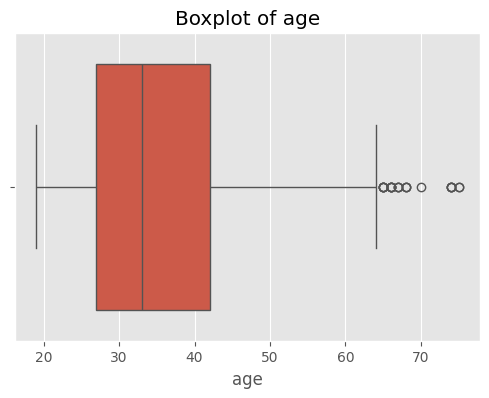

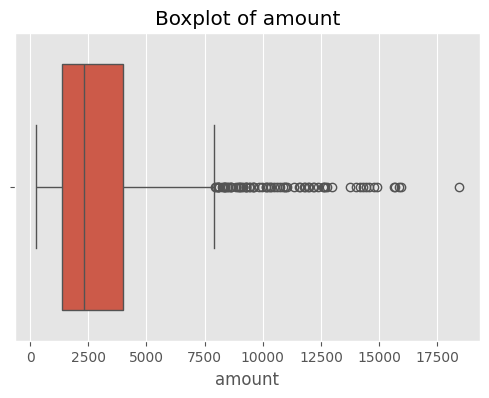

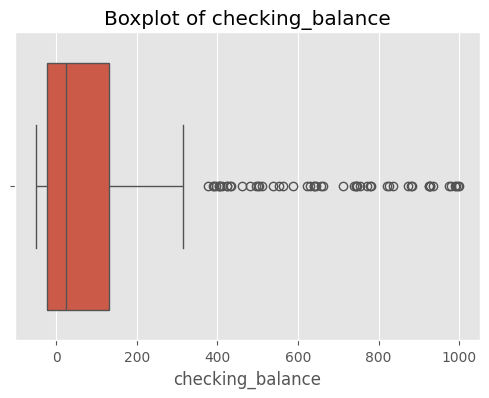

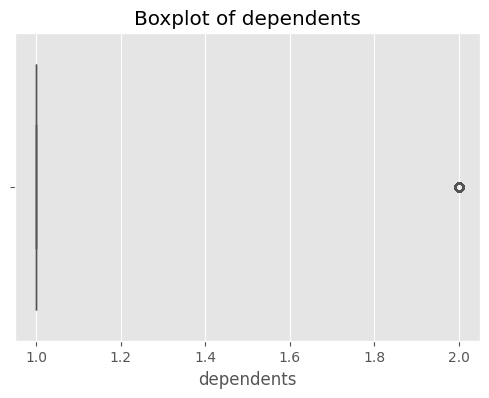

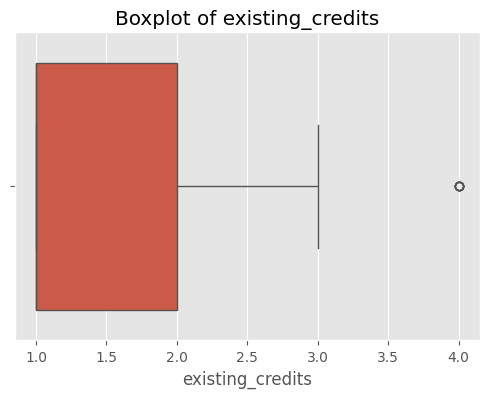

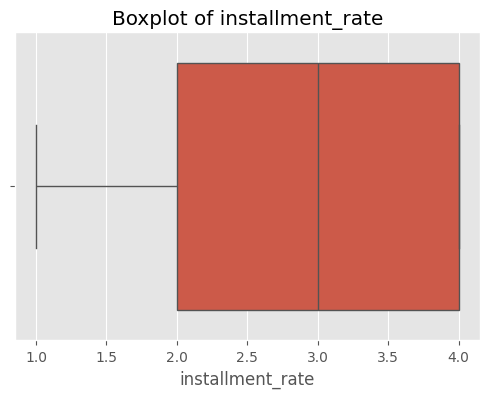

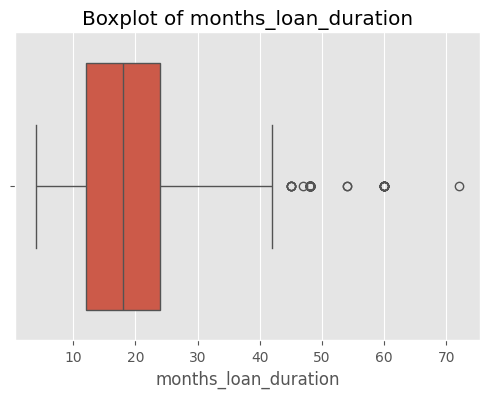

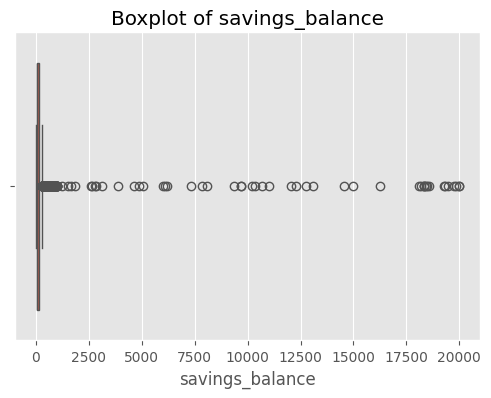

In [14]:
# Checking for outliers in the numeric features
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns.difference(['telephone','default'])
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

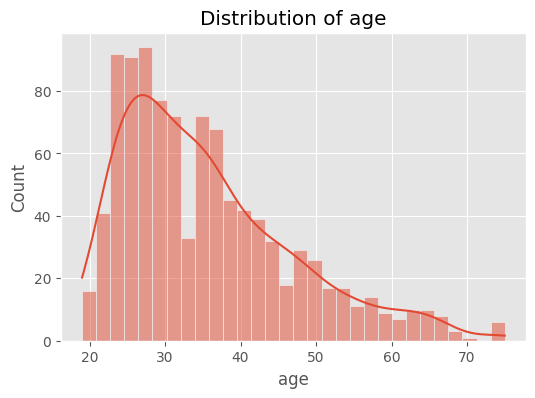

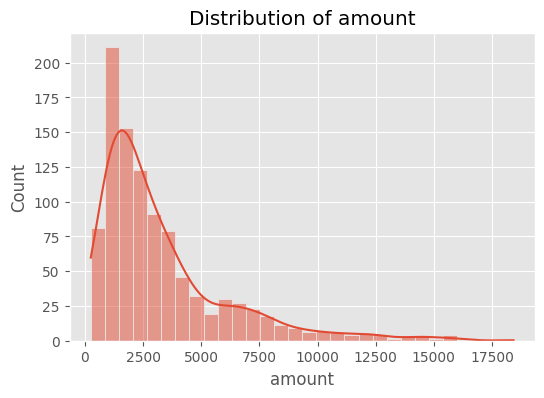

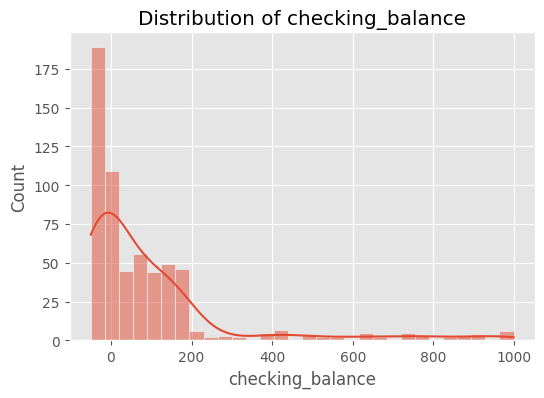

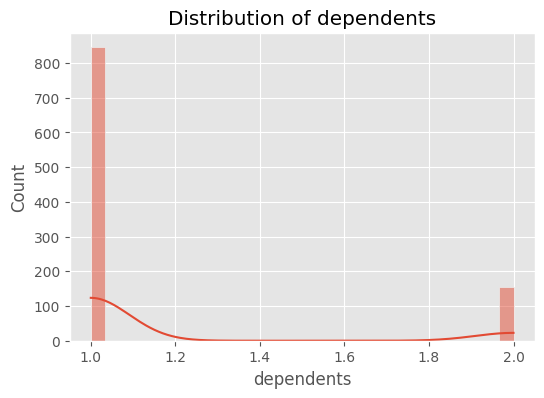

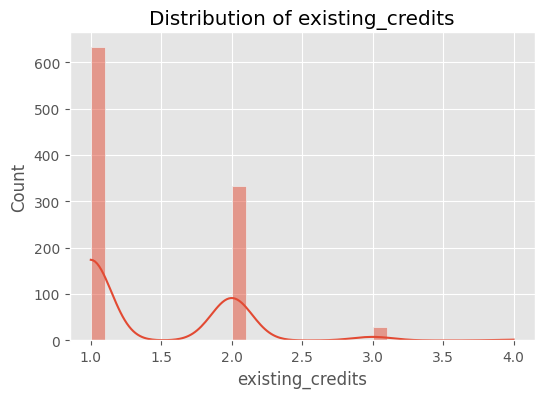

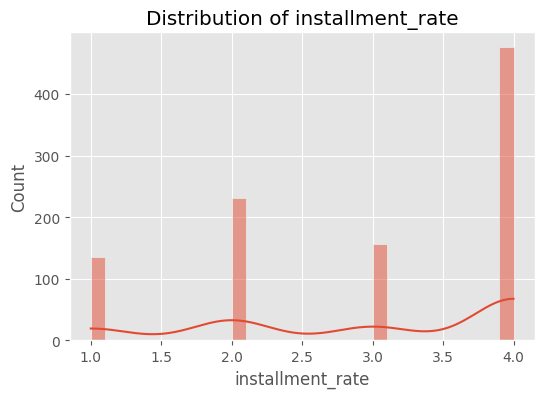

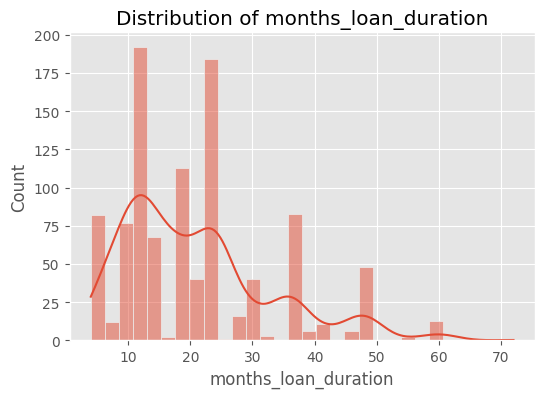

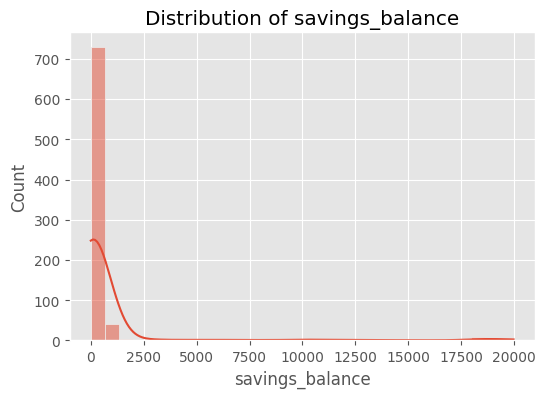

In [28]:
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

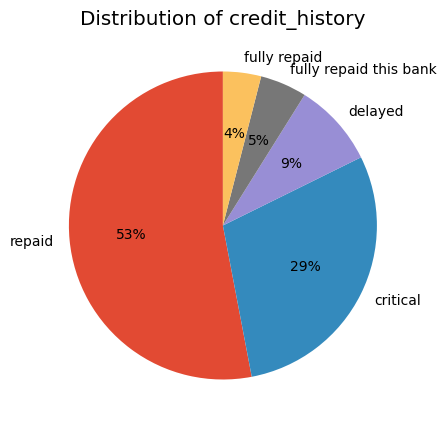

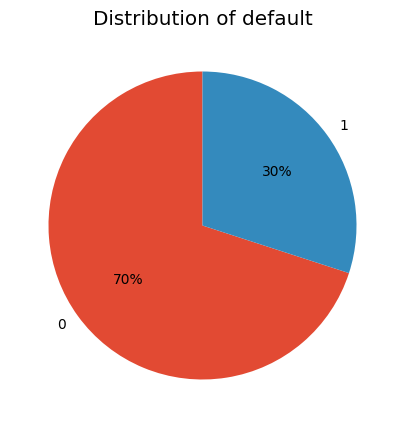

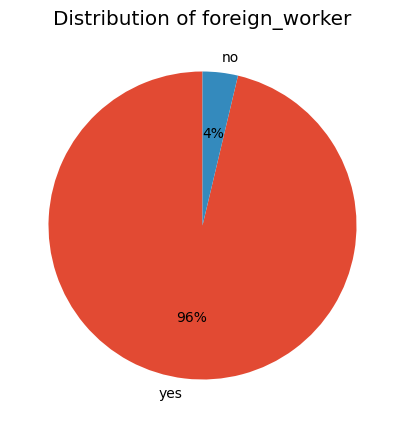

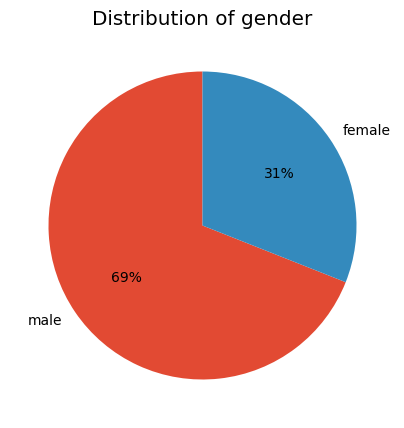

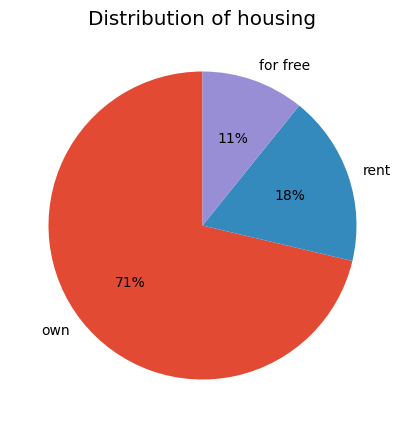

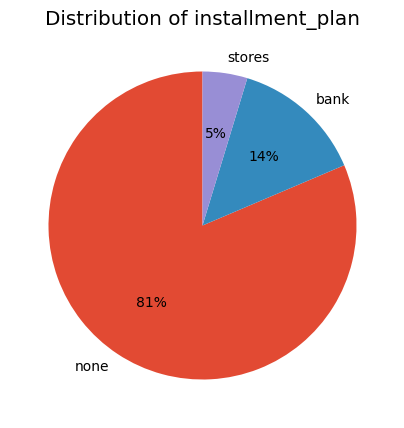

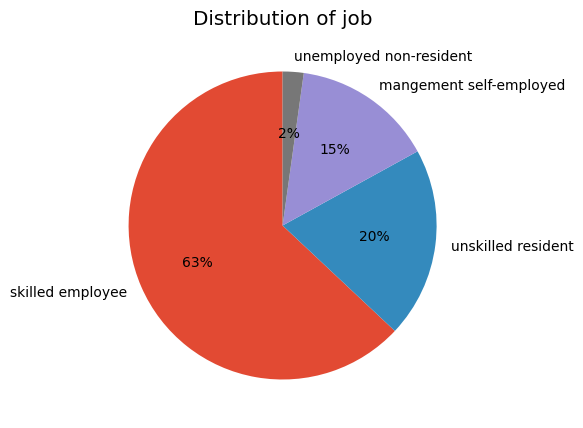

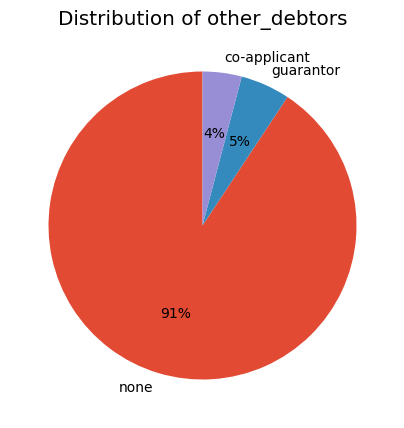

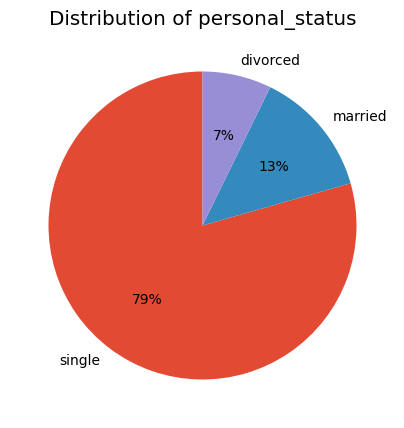

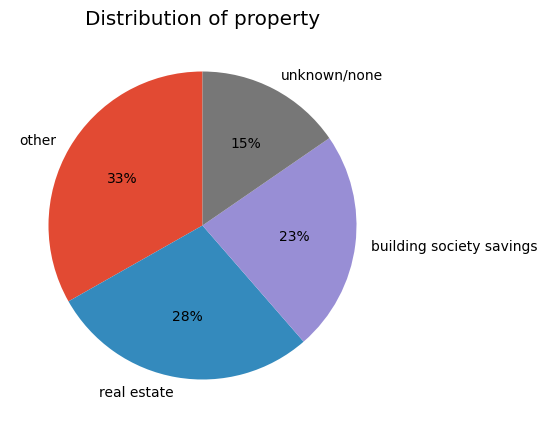

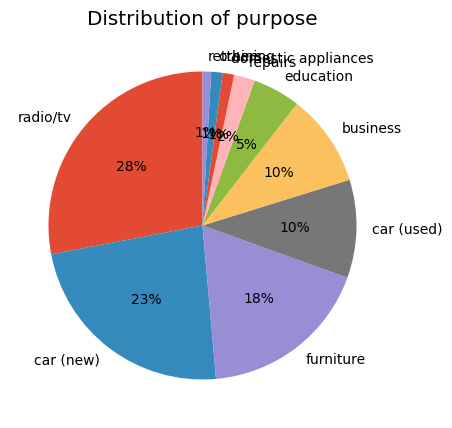

In [15]:
# Distibution plots for the features
# excluding residence_history and employment_length, as they have unusual number of categories
categorical_columns = (df.select_dtypes(include=['object', 'category']).columns
    .union([target_column])).difference(["employment_length","residence_history"])

for i in categorical_columns:
    df[i].value_counts().plot.pie(
        autopct="%1.0f%%",   # show percentages
        figsize=(5,5),    
        startangle=90       # rotate for better readability
    )
    plt.title(f"Distribution of {i}")
    plt.ylabel('')
    plt.show()

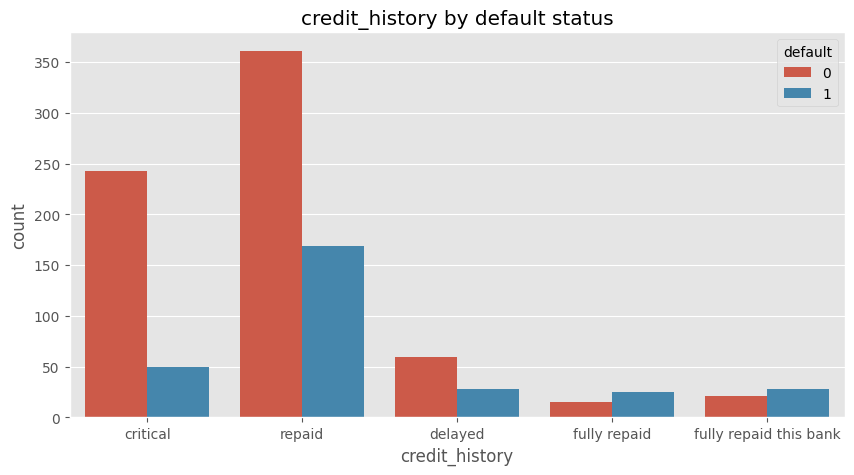

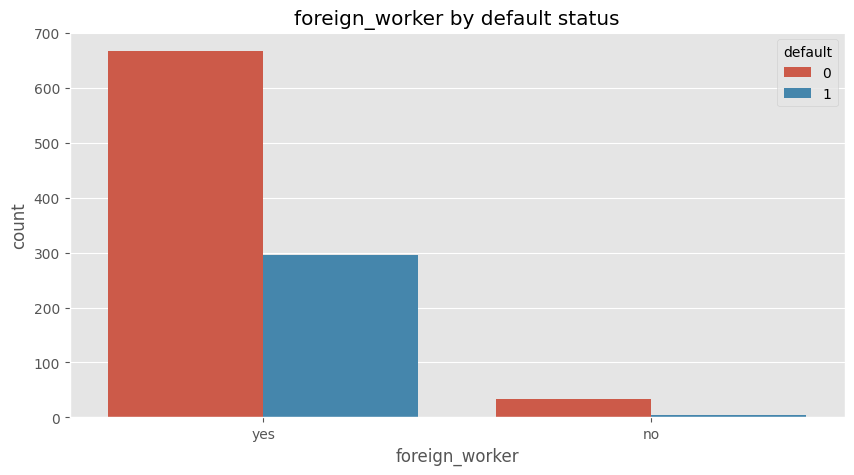

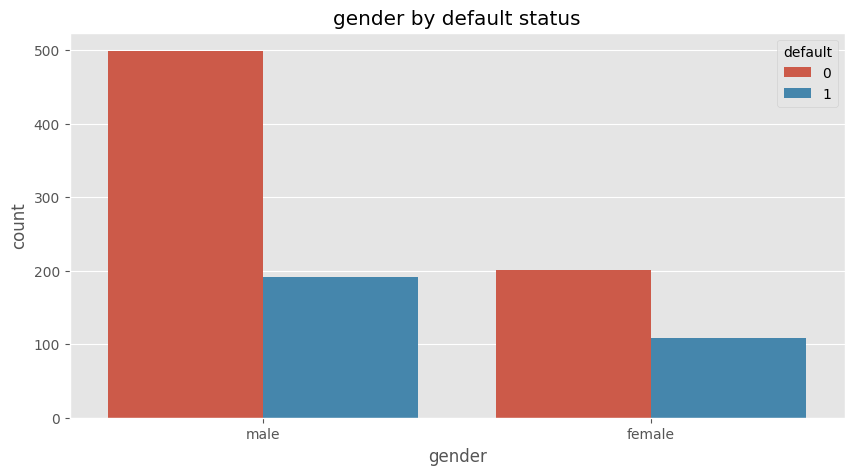

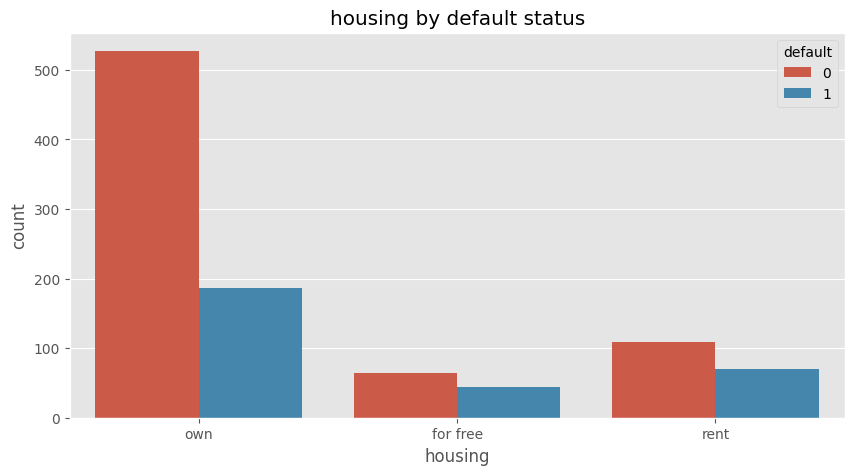

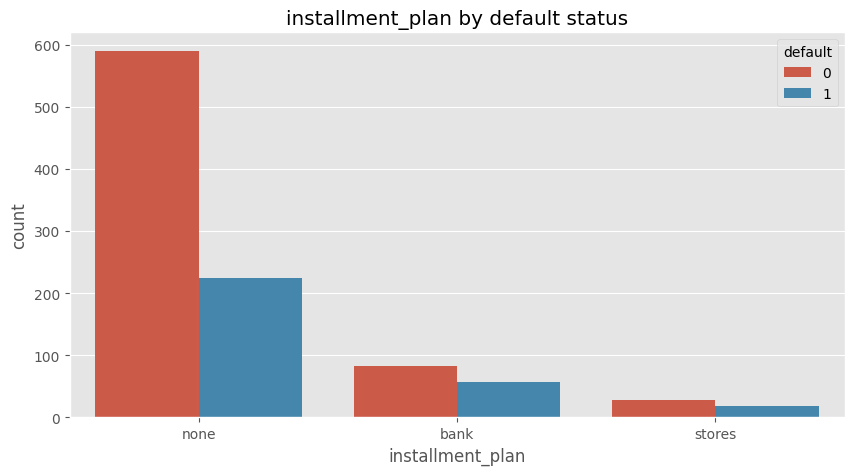

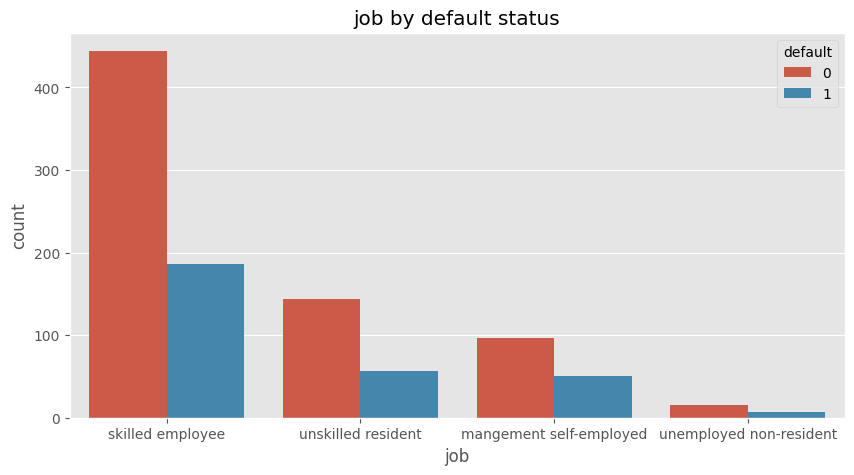

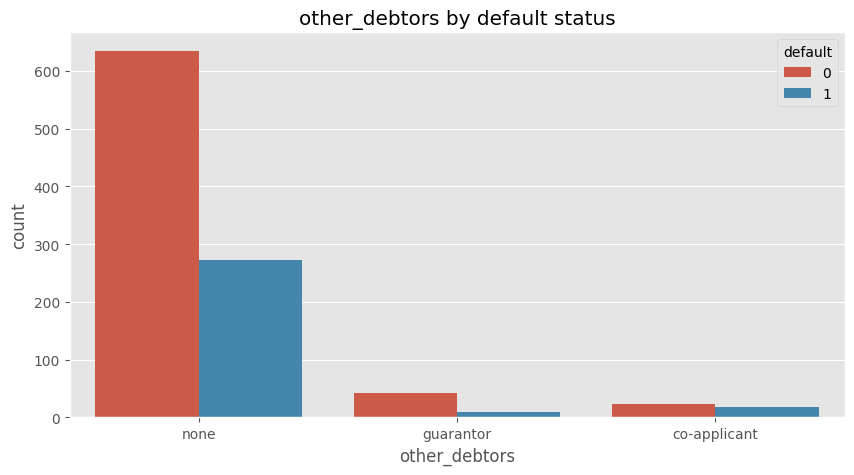

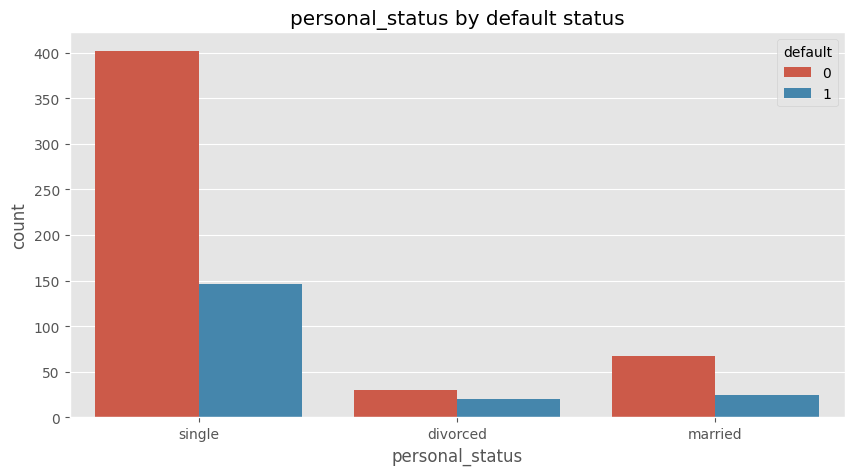

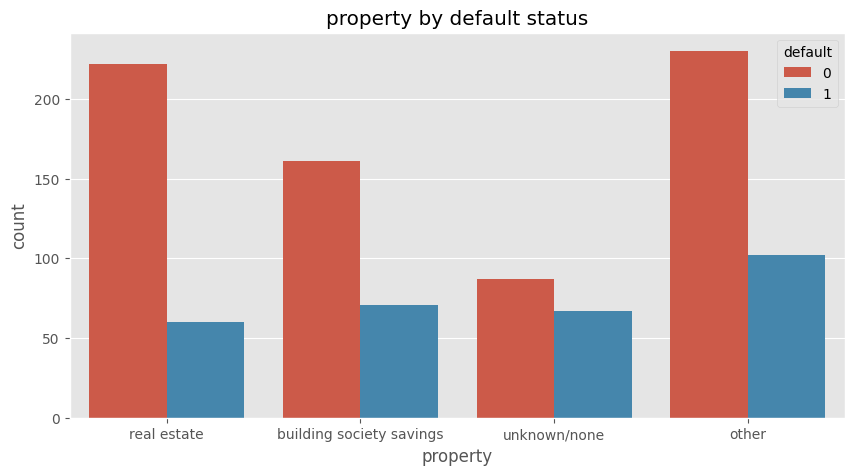

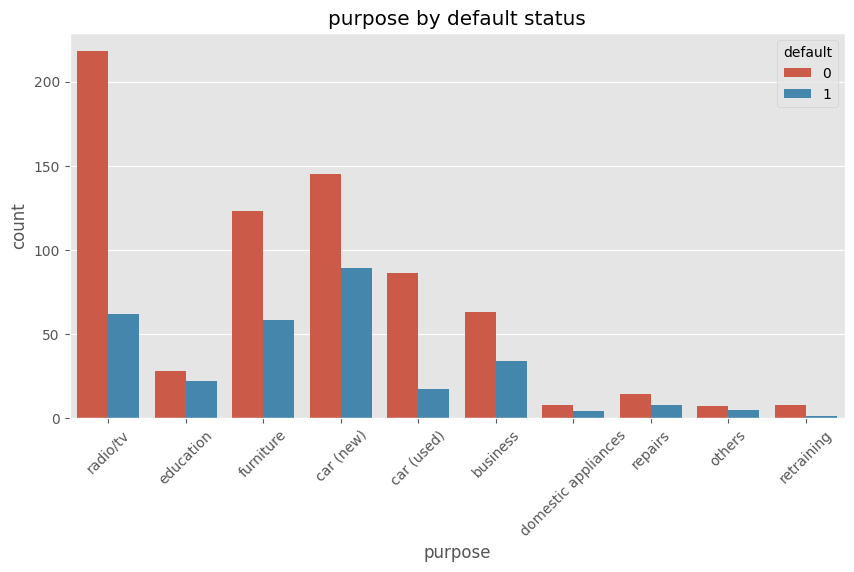

In [16]:
# obtain distribution plot for the categorical feautures against the target column 
categorical_columns = categorical_columns.difference([target_column])

# categoric features visualization
data_categoric = df.loc[:, categorical_columns]
for i in categorical_columns:
    plt.figure(figsize=(10,5))
    sns.countplot(x = i, data = df, hue=target_column)
    plt.title(f"{i} by {target_column} status")
    if i == "purpose":
        plt.xticks(rotation=45)

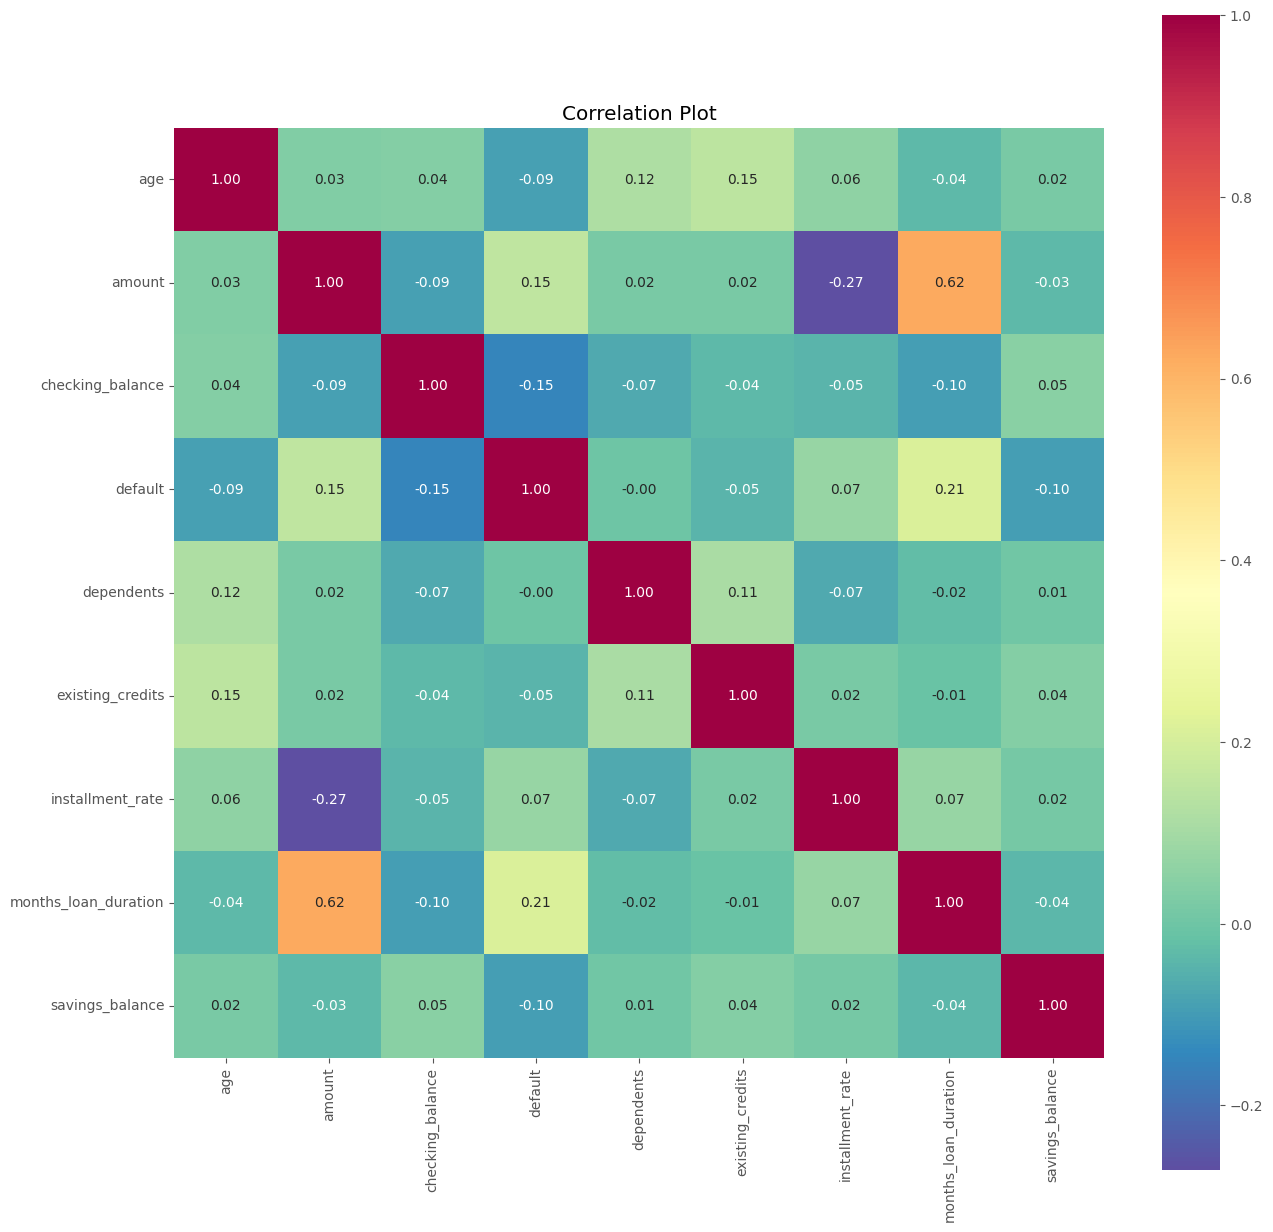

In [17]:
# Obtain Correlation matrix between the numeric features
cormat(df)

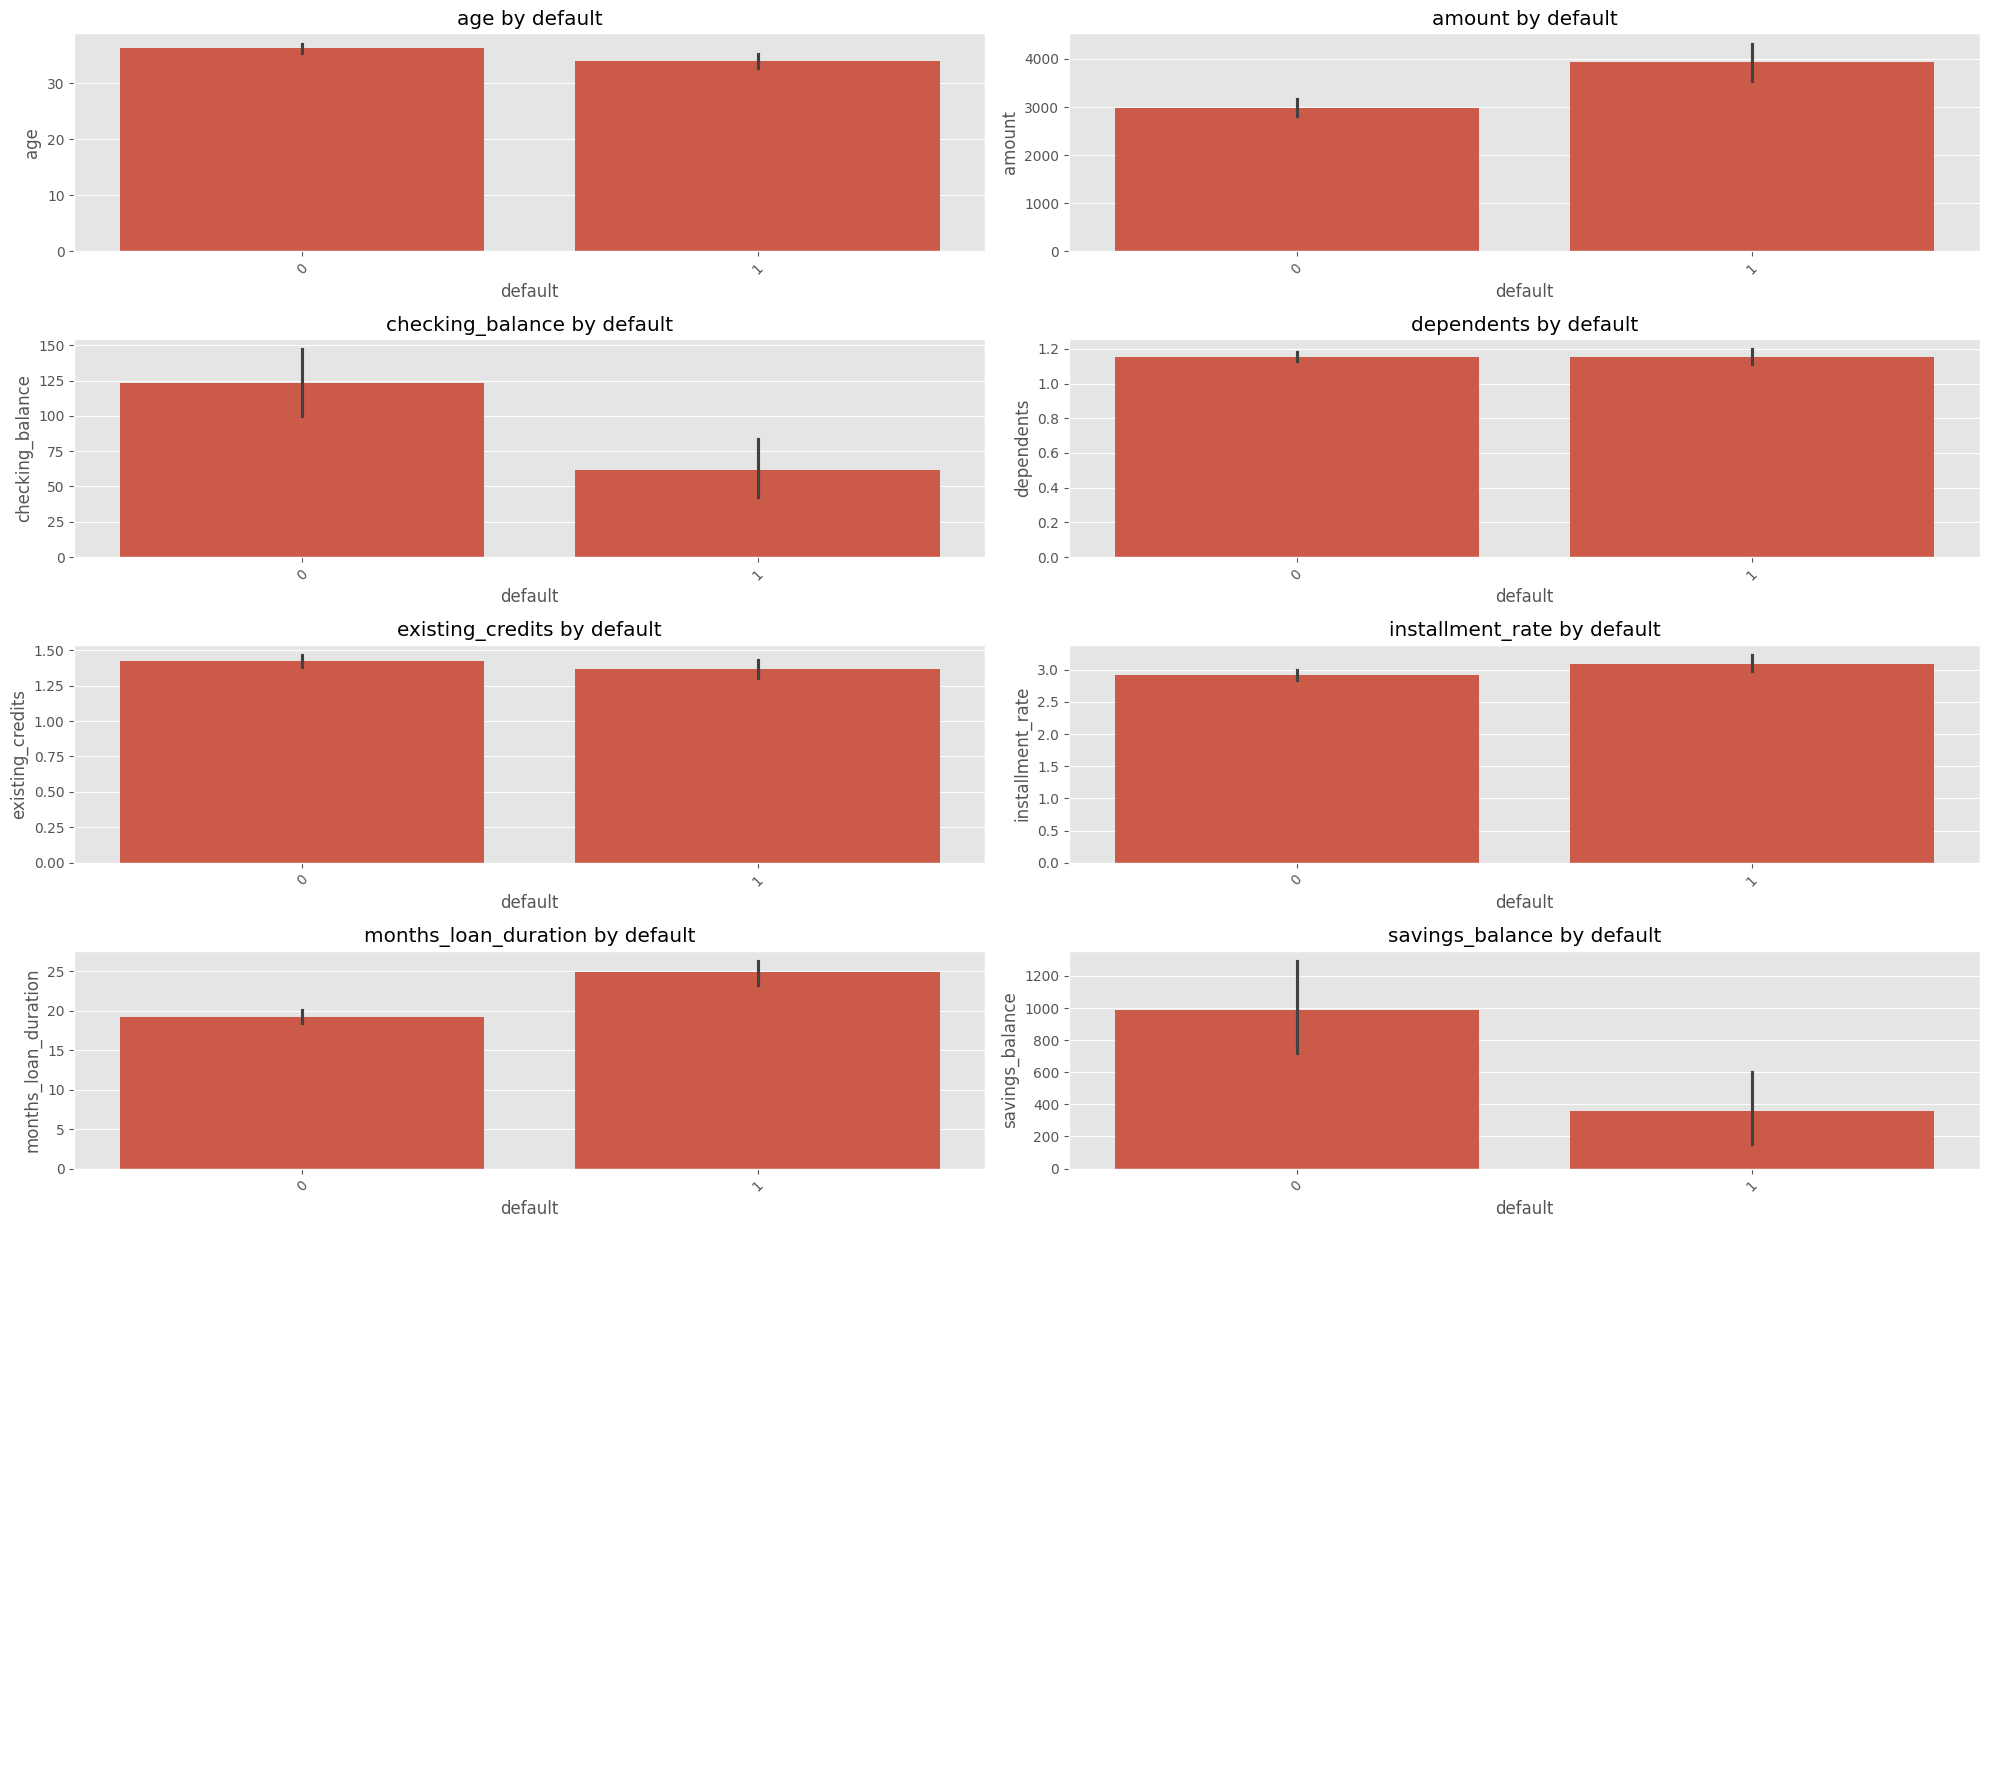

In [88]:
# Obtain distribution of the numeric features by the target 
barplot(target_column,df)

### Some Insights from the Dataset

* No duplicated records in the dataset
* Total records in the dataset is 1000, with 22 features.
* Features such as *checking_balance
savings_balance,employment_length,personal_status,residence_history,telephone* have missing records.
  - missingness in `checking_balance` could indicate `no checking account`
  - missing data in `savings_balance` could also indicate `no saving account`
  - missing data in `employment_length` could imply the person is `unemployed`.
  - someone without `residence_history` record could be new in the area.
  - missing record for `personal_status` could be due to its sensitivity.
  - missing `telephone` could imply no telephone is registered under the customer’s name"
* The credit history data showed that just 4% of these customers have fully repaid their previous loans with other banks, while 5% have fully repaid their previous loans with this bank. In addition, 29% have bad credit history, while 53% have existing loans being repaid as agreed, and 9% of these customers have records of delayed repayment.
* Defaulters in the dataset tend to have borrowed larger loan amounts on average compared to non-defaulters. This suggests that higher loan amounts may be associated with increased risk of default, although this effect could be influenced by other factors such as income and loan tenor.
* Both checking and savings balances exhibit similar patterns with respect to default risk. Customers with lower account balances are more likely to default, suggesting that limited liquidity and weaker financial buffers increase repayment risk.
* There are more than 2x males as compared to females in the dataset, which suggests a potential systematic bias towards females.
* In the dataset, bad credits tend to have longer tenors compared to good credits. This suggests that longer repayment durations may increase the risk of default, possibly due to higher uncertainty and repayment burden over time.
* There's no significant correlations among the numeric features, except between loan amount and tenor (r=0.62), which is understandable since borrowers taking larger loans tend to also take them over longer durations.
* `dependents` variable has zero correlation with the default variable, suggesting dependents variable is simply a noise feature.
* Outliers seem to be affecting the following features:`amount`, `checking_balance`,`savings_balance`
* **residence_history**, and **employment_length** have high number of categories.

### Strategies to Address Issues in the Dataset

* **Missing Records**: Missing values will be handled using a pipeline that integrates a `SimpleImputer` with a constant value, along with a corresponding missing-value flag for each feature. The flag serves as an additional signal to the model, capturing information that may be predictive of the target.
* **Imbalance dataset**: The dataset is moderately imbalanced, with 30% bad credits and 70% good credits. To address this and improve model generalization, the SMOTE (Synthetic Minority Over-sampling Technique) will be applied to create synthetic samples of the minority class.
* Fairly **strong correlation** between loan amount and tenor: Some tree-based models (RandomForest, XGBoost) will be considered during model training, since they are less sensitive to correlated features.
* **Exclusion of Sensitive/redundant features**:
    - `gender` will be excluded, it is a protected attribute in most jurisdictions and may introduce bias or discriminatory outcomes. Nevertheless, fairness assessment will be conducted to validate the model’s behavior with respect to gender attributes.
    - Additionally, `foreign_worker` provides little predictive value, as **96%** of the observations fall under the same category (foreigner).
    - `telephone` does not give any predictive information, and will also be excluded from the dataset.
    - `dependents` feature has zero correlation with the credit risk variable, making it a redundant variable in the dataset. This will also be dropped.
* **Outliers**: `RobustScaler` will be used to handle the outlying points gracefully, couple with the fact that tree-based models are robust to outliers.

**Note: Most of these strategies will be carried out during data preprocessing and model pipeline development** 



### Data Preprocessing

In this section, the following will be done
- The dataset will be split into training and testing datasets (using 80:20)
- Sensitive/redundant features (gender,telephone,foreign_worker,dependents,tenor) will be removed from the training and testing data

In [31]:
# Set the output folder for training and testing dataset, as well as the test dataset size
output_dir = "./processed_data"
test_size = 0.20

In [32]:
# The custom `preprocess_data` function achieve all of these at a go
preprocess_data(df, target_column, output_dir,test_size)

Datasets saved to ./processed_data


In [6]:
# Load the datasets
X_train = load_data("./processed_data/X_train.csv")
X_test = load_data("./processed_data/X_test.csv")

y_train = load_data("./processed_data/y_train.csv")
y_test = load_data("./processed_data/y_test.csv")

protected_feature_train = load_data("./processed_data/protected_train.csv")
protected_feature_test = load_data("./processed_data/protected_test.csv")

In [34]:
# Check the datasets
X_train.shape, X_test.shape

((800, 17), (200, 17))

In [35]:
y_train.shape, y_test.shape

((800, 1), (200, 1))

In [36]:
protected_feature_train.shape, protected_feature_test.shape

((800, 1), (200, 1))

### Model Training And Evaluation

In this section, a unified pipeline that will handle the following was developed.

* **Features Engineering**
   * Introduce flags for missing data
   * Derive new features: `total_balance`,`loan_to_balance`,`age_bucket`,`loan_amount_bucket`,`credit_history_severity`.
   * Interactive Features: `employment_x_amount`,`balance_x_savings`
* **Missing data** - computed using `SimpleImputer` (**most frequency** for categorical, **constant=0** for numerics) 
* **Dataset imbalance**: addressed using SMOTE to generate synthetic samples for the minority class ("bad" credit risk) during model training.
* **Data Normalization**
  - Standardization for numerics
  - OneHotEncoding for categorical variables
* **Model training & Evaluation**
  - Trained four models Random Forest, XGBoost, KNN, Logistic Regression
  - Handled **overfitting** based on Feature importance selection
  - Evalaute model performance on test datasets

Model: LogisticR
Validation Dataset Performance
ROC AUC: 0.66
Recall: 0.58
f1: 0.48
Balanced Accuracy: 0.61


Training Dataset Performance
ROC AUC: 0.79
Recall: 0.72
f1: 0.60
Balanced Accuracy: 0.71


Test Dataset Performance
Accuracy: 0.75
Precision: 0.55
Recall: 0.80
F1 Score: 0.65
ROC AUC: 0.78




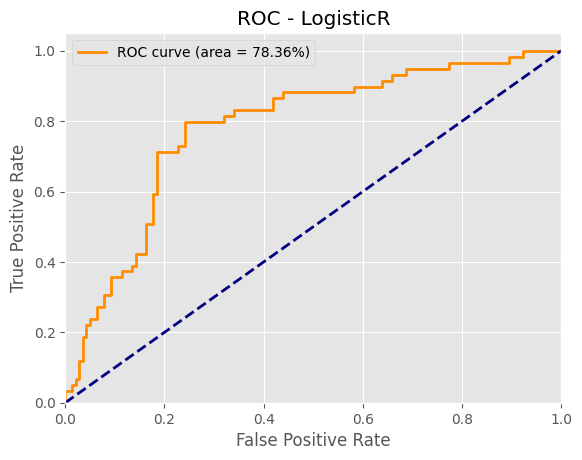

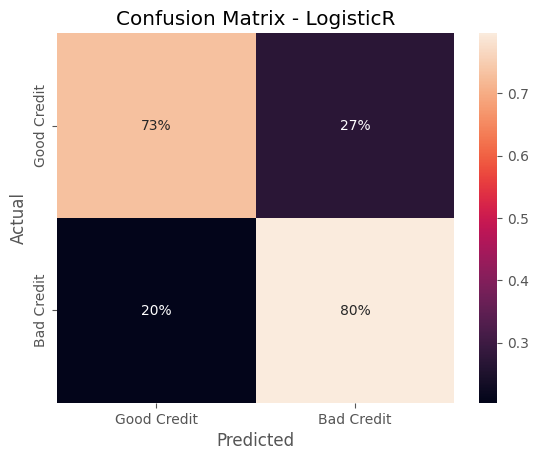

Classification Report for LogisticR:

              precision    recall  f1-score   support

           0       0.90      0.73      0.80       141
           1       0.55      0.80      0.65        59

    accuracy                           0.75       200
   macro avg       0.72      0.76      0.73       200
weighted avg       0.79      0.75      0.76       200

Model: RandomForest
Validation Dataset Performance
ROC AUC: 0.73
Recall: 0.55
f1: 0.53
Balanced Accuracy: 0.66


Training Dataset Performance
ROC AUC: 0.86
Recall: 0.67
f1: 0.67
Balanced Accuracy: 0.77


Test Dataset Performance
Accuracy: 0.81
Precision: 0.69
Recall: 0.68
F1 Score: 0.68
ROC AUC: 0.84




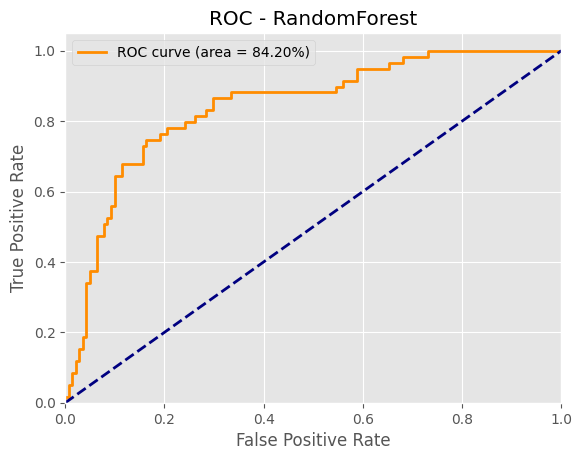

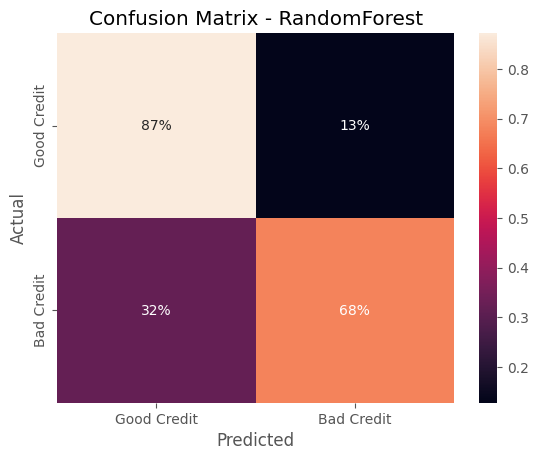

Classification Report for RandomForest:

              precision    recall  f1-score   support

           0       0.87      0.87      0.87       141
           1       0.69      0.68      0.68        59

    accuracy                           0.81       200
   macro avg       0.78      0.78      0.78       200
weighted avg       0.81      0.81      0.81       200

Model: XGBoost
Validation Dataset Performance
ROC AUC: 0.74
Recall: 0.43
f1: 0.47
Balanced Accuracy: 0.63


Training Dataset Performance
ROC AUC: 1.00
Recall: 1.00
f1: 1.00
Balanced Accuracy: 1.00


Test Dataset Performance
Accuracy: 0.74
Precision: 0.57
Recall: 0.58
F1 Score: 0.57
ROC AUC: 0.79




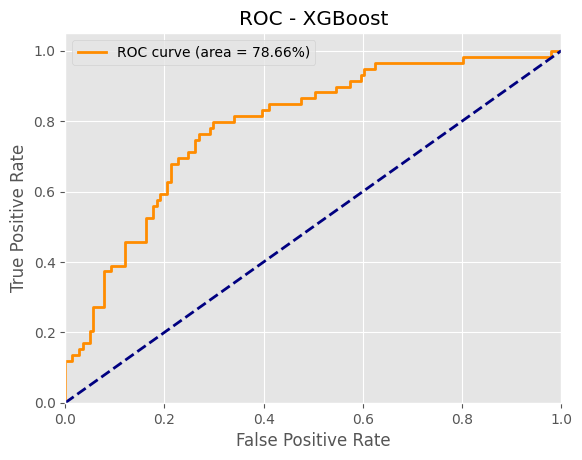

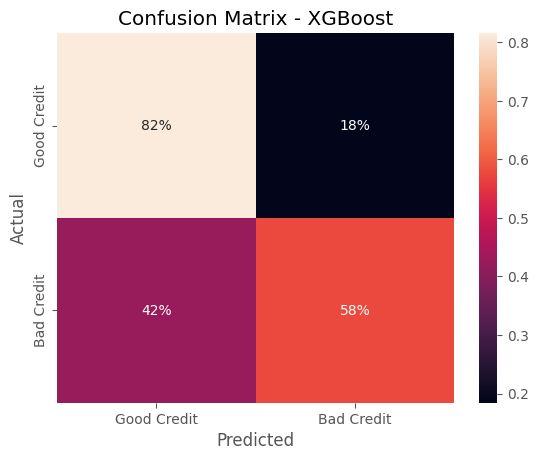

Classification Report for XGBoost:

              precision    recall  f1-score   support

           0       0.82      0.82      0.82       141
           1       0.57      0.58      0.57        59

    accuracy                           0.74       200
   macro avg       0.69      0.70      0.69       200
weighted avg       0.75      0.74      0.75       200



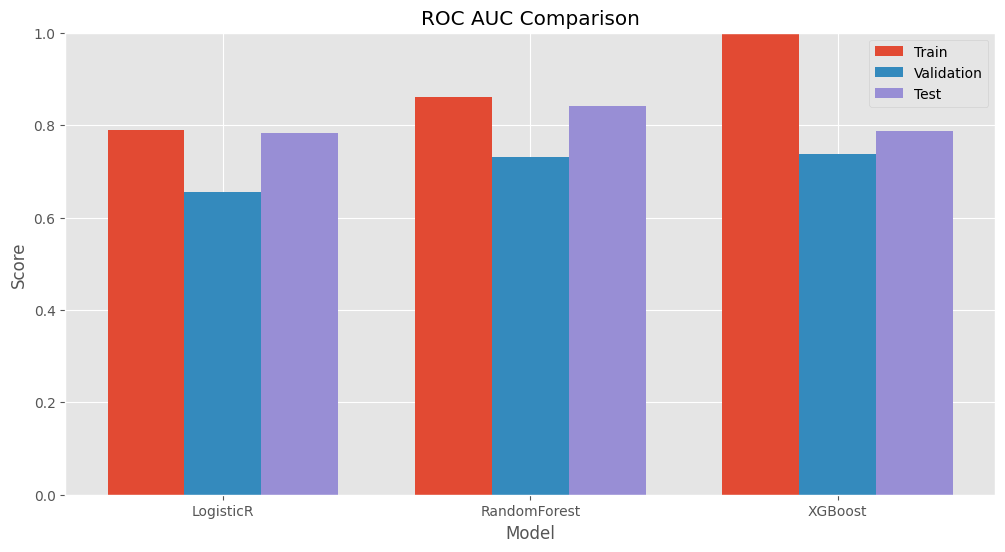

In [12]:
# Train all the models using the pre-defined pipeline, and return the performance metrics
train_and_evaluate_model(X_train, X_test, y_train, y_test,cv)

#### Key Observations

1 Logistic Regression:

- Training ROC-AUC is 0.79, but validation drops to 0.66, which indicates some overfitting. However, the test ROC-AUC 0.77 confirms that generalization might not be a concern.

2 Random Forest:

- Training ROC-AUC ~0.86 and validation ROC-AUC ~0.73, indicating good generalization. Test ROC-AUC is very closed to training, which confirms consistent performance.

3 XGBoost:

- Training ROC-AUC ~1.00 and validation ROC-AUC ~0.73, indicating bad generalization. Test ROC-AUC also dropped to 0.79, which confirms that generalization is a concern.


Overall, Random Forest had the most stable performance of the 3 models


### Model Hyperparameter Tuning 

Here we will use 5-fold stratified sampling to get more reliable metrics rather than relying on a single training/testing split, to assess generalization of the models.

In [22]:
# Cross_validate the models, and return the best among the competing models

scoring = {
    "roc_auc": "roc_auc",
    "recall": "recall",
    "f1": "f1",
    "balanced_acc": "balanced_accuracy"
}

model_val(X_train,y_train,cv,scoring)

Logistic Regression: 0.6096938775510204
Random Forest: 0.5558673469387755
XGBoost: 0.6598639455782312

Best Model: XGBoost | Score: 0.6598639455782312


### Tuned Model Performance

In [25]:
model_grid = {'Logistic':load_model(r"C:\Users\Aderoju\Desktop\Python Project\Credit Risk Modelling\model\cv_Logistic Regression.pkl"),
              'Random Forest':load_model(r"C:\Users\Aderoju\Desktop\Python Project\Credit Risk Modelling\model\cv_Random Forest.pkl"),
              'XGBoost':load_model(r"C:\Users\Aderoju\Desktop\Python Project\Credit Risk Modelling\model\cv_XGBoost.pkl")}

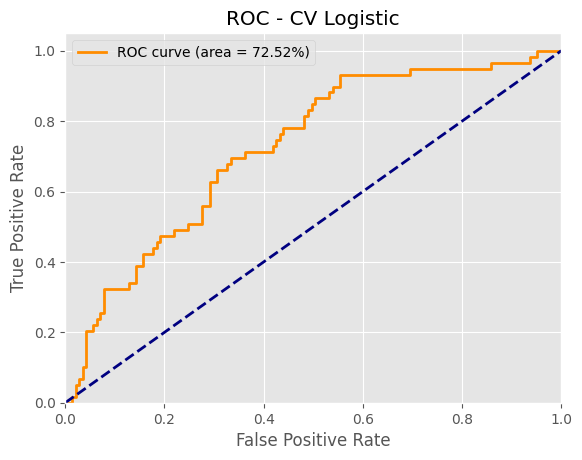

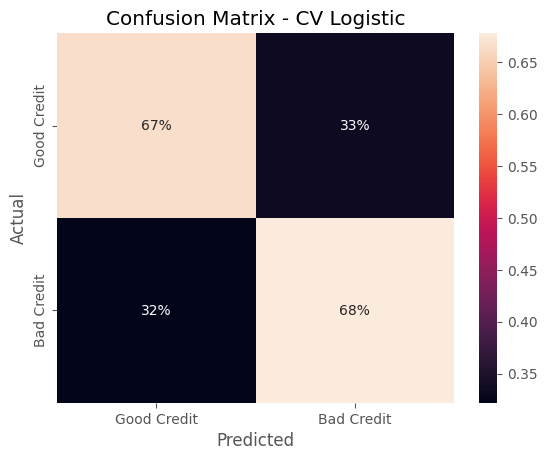

Logistic Model Performance Report
{'accuracy': [0.67], 'precision': [0.45977011494252873], 'recall': [0.6779661016949152], 'f1_score': [0.547945205479452], 'roc_auc': [0.7252073566534439]}

Kindly check './report' for the reports


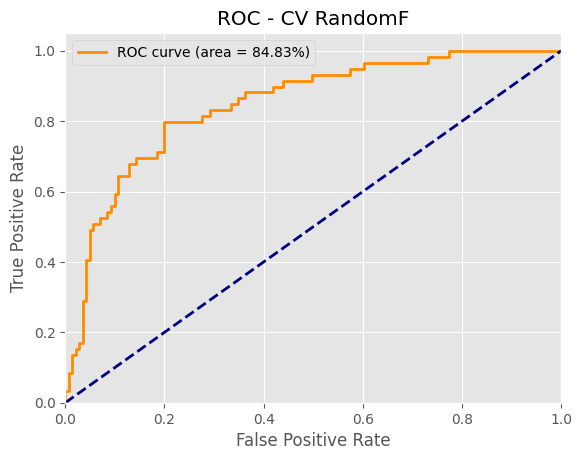

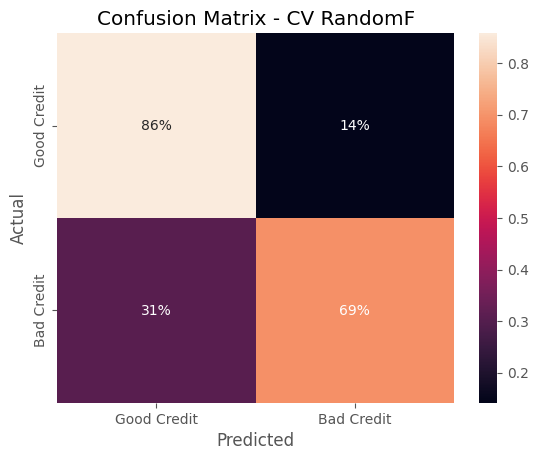

RandomF Model Performance Report
{'accuracy': [0.81], 'precision': [0.6721311475409836], 'recall': [0.6949152542372882], 'f1_score': [0.6833333333333333], 'roc_auc': [0.8482990744079817]}

Kindly check './report' for the reports


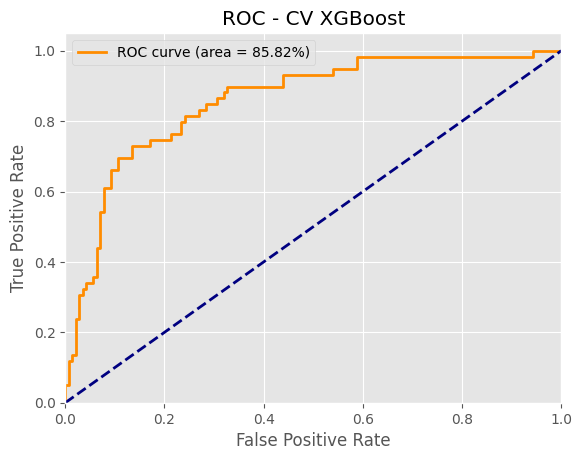

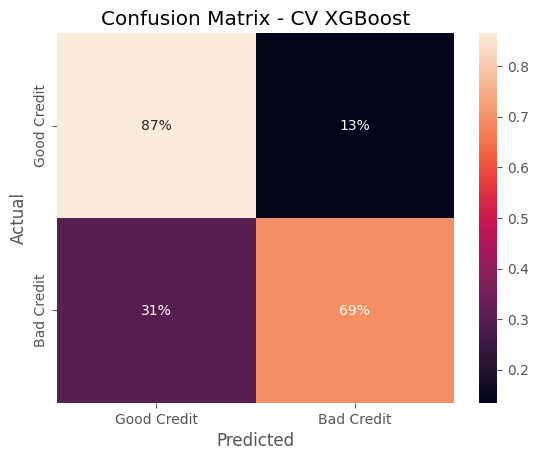

XGBoost Model Performance Report
{'accuracy': [0.815], 'precision': [0.6833333333333333], 'recall': [0.6949152542372882], 'f1_score': [0.6890756302521008], 'roc_auc': [0.8581560283687943]}

Kindly check './report' for the reports


In [20]:
for name, pipeline in model_grid.items():
    model_report(X_test,y_test,pipeline,name)

The best tuned model (XGBoost) correctly predicts 81.5% overall, and the model correctly identifies about 72.9% of bad credit risk



### Fairness Check

Here we will do fairness check for gender to ascertain, model fairness irrespective of gender category 

In [24]:
# Fairness Check for gender
sensitive = protected_feature_test["gender"]
for name ,pipeline in model_grid.items():

    # First obtain prediction for testing datasete using the best model
    y_pred = pipeline.predict(X_test)
    print(f"Fairness Check for {name}")
    fairness_check(y_test,y_pred,sensitive)
    print()

Fairness Check for Logistic
Performance by group:
         accuracy  selection_rate       tpr
gender                                    
female  0.631579        0.543860  0.812500
male    0.692308        0.384615  0.627907
Demographic parity difference: 0.1592442645074224
Demographic parity ratio: 0.707196029776675
Equalized odds difference: 0.18459302325581395

Fairness Check for RandomF
Performance by group:
         accuracy  selection_rate       tpr
gender                                    
female  0.719298        0.315789  0.562500
male    0.804196        0.300699  0.674419
Demographic parity difference: 0.015090172984909833
Demographic parity ratio: 0.9522144522144522
Equalized odds difference: 0.11191860465116277

Fairness Check for XGBoost
Performance by group:
         accuracy  selection_rate       tpr
gender                                    
female  0.736842        0.473684  0.875000
male    0.769231        0.391608  0.767442
Demographic parity difference: 0.0820758189179

### Interpretation

* Overall, the Random Forest achieved the best fairness perfromance.
* The Demographic Parity Ratio (0.95) exceeds the commonly referenced 0.80 threshold (80% rule), indicating no statistically significant adverse impact under this criterion.

* The Demographic Parity Difference (1.5%) indicates extremely small variation in selection rates across gender.

* However, Equalized Odds Difference (11.1%) suggests little variation in error rates between the gender groups, which is aboveslightly typical internal tolerance thresholds (10%).

**Other models such as Logistic, and XGBoost exhibit severe disparity**

### Model Selection

In terms of Performance, Random Forest achieved similar performance to the best tuned model, and it is simpler compared to other models. The only major improvement from the best tuned model is ROC AUC. F1 and Recall are identical.

In conclusion, Random Forest is the best model overall for predicting credit risk.

In [26]:
best_model_name = 'Random Forest'
pipeline = model_grid[best_model_name]


### Feature Importance

Next, we will look at the importance of the features in the dataset to predicting defaulting behaviour, as well as the direction of their effects on credit risk prediction.

1. We will use feature importance method of `Logistic Regression` to check the most/least contributing features
2. We will then use SHAP explainer to determine the direction of this effect

In [27]:
# Get transformed feature names
feature_names = pipeline[:-1].get_feature_names_out()

# Now align importances
model = pipeline.named_steps['classifier']   # obtain the model object from the pipeline

# store the importances in a dataframe
if 'logistic' in best_model_name.lower():
    importances = pd.Series(
        model.coef_[0], 
        index=feature_names
    ).sort_values(key=abs, ascending=False)
else:
    importances = pd.Series(model.feature_importances_, index=feature_names)


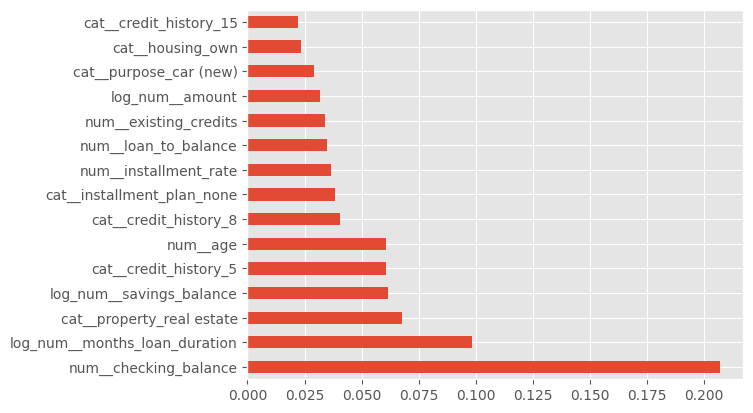

In [28]:
#plot the importance of the most contributing features
importances.nlargest(15).plot(kind='barh')
plt.show()

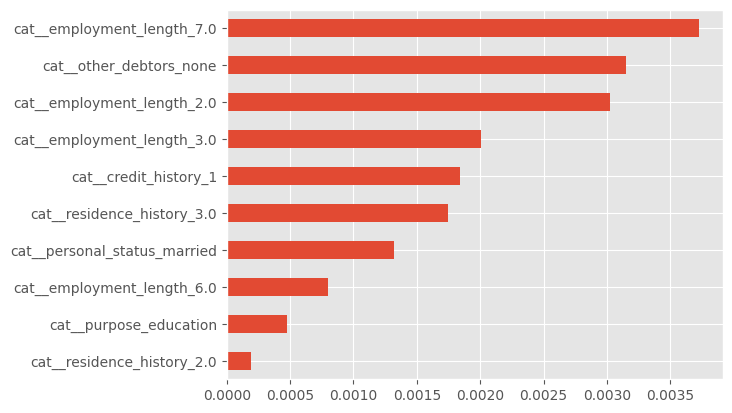

In [29]:
#plot the importance of the least contributing features
importances.nsmallest(10).plot(kind='barh')
plt.show()

In [30]:
# Transform test features (exclude classifier in pipeline)
X_transformed = pipeline[:-1].transform(X_test)

if 'logistic' in best_model_name.lower():
    explainer = shap.LinearExplainer(
    model,
    X_transformed
)

else:
    # Create explainer the model
    explainer = shap.TreeExplainer(model)

# Compute SHAP values
shap_values = explainer(X_transformed)

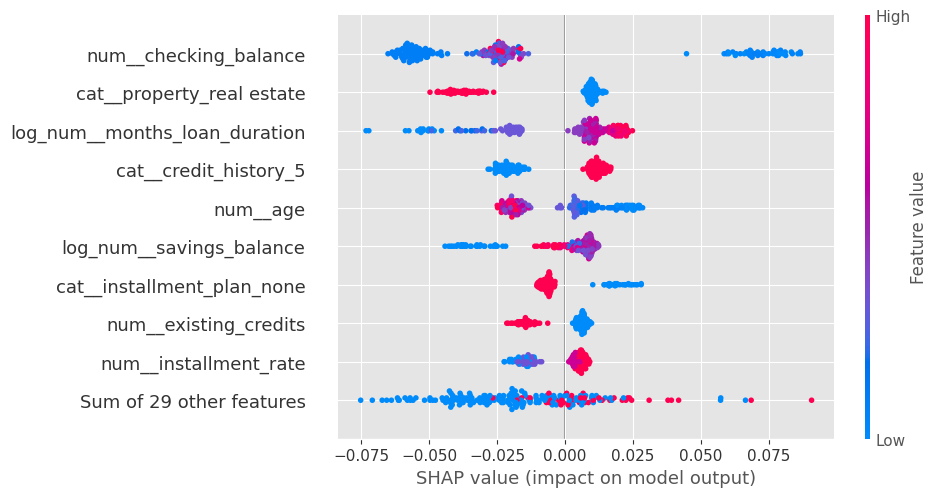

In [34]:
if 'random' in best_model_name.lower():
    shap_values = shap_values[:, :, 1]

shap.plots.beeswarm(shap_values)

### Interpretation

The results from above suggest:
* Checking balance, Age, Credit history, Loan tenor, and installment rate are the most influential factors in predicting credit risk.
* Higher values for installment rate, and loan tenor increase default risk
* Younger individuals increase probability of default.

### Conclusion

In this analysis, multiple machine learning models were developed to predict credit risk using the German Credit dataset. The objective was not only to maximize predictive performance but also to ensure fairness, stability, and regulatory defensibility.

#### Key Drivers of Credit Risk

Feature importance analysis (via SHAP and model coefficients) identified the following variables as the most influential predictors of default risk:

Checking account balance, Loan duration (tenor), Savings balance, Installment rate, Customer age, Number of existing loans and Credit history. These variables align with established credit risk theory, reinforcing the economic validity of the model.

#### Model Performance and Generalization

Three baseline models were evaluated: Logistic Regression, Random Forest, and XGBoost.

Although the baseline XGBoost model achieved perfect training performance (100% accuracy and recall), validation results revealed clear overfitting. Consequently, model selection prioritized generalization performance on unseen data rather than training metrics.

After hyperparameter tuning:

XGBoost came out as the best performing with ROC AUC of 0.84, Recall of 79.6%, and Accuracy of 74.5%.

#### Fairness Assessment

Fairness was evaluated using gender as a protected attribute. Metrics assessed included:Demographic Parity Difference
,Demographic Parity Ratio (80% rule benchmark), Equalized Odds Difference.

The Random Forest results indicate minimal disparity and fall comfortably within commonly accepted fairness thresholds.

Tuned XGBoost,

Although not breaching the 80% rule, XGBoost exhibited noticeably higher disparity and exceeded typical internal tolerance thresholds for equalized odds.

#### Model Selection Rationale


While XGBoost achieved slightly higher ROC AUC, it demonstrated increased demographic disparity and greater complexity. Random Forest achieved comparable recall and F1 performance with substantially stronger fairness metrics and higher interpretability.

Given that recall performance was similar across models and fairness is a critical requirement in credit decision systems, Random Forest was selected as the preferred model.

However, due to the high Equalized Odds Ratio (11.1%), fairness metrics will require ongoing monitoring post-deployment to detect potential drift or emerging disparities across demographic groups.

#### Final Recommendation

* Random Forest is recommended as the production model due to its balance of: Competitive predictive performance, Strong fairness profile, Regulatory defensibility, Generalization stability.

* XGBoost may be maintained as a challenger model for future benchmarking under controlled fairness constraints.
